In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from train import train_model

In [2]:
df = pd.read_csv("../data/processed/features.csv")

## Data Exploration

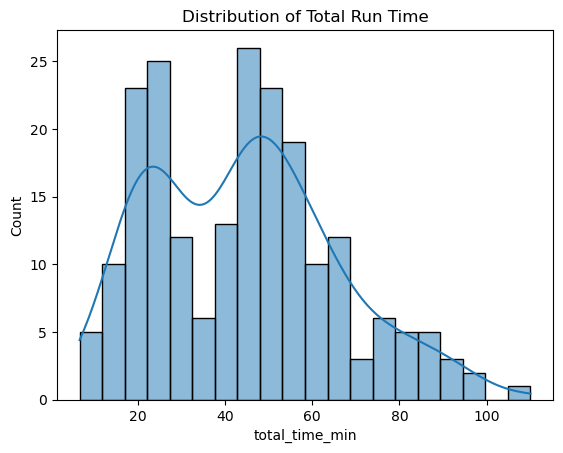

In [3]:
sns.histplot(df['total_time_min'], bins=20, kde=True)
plt.title("Distribution of Total Run Time")
plt.show()

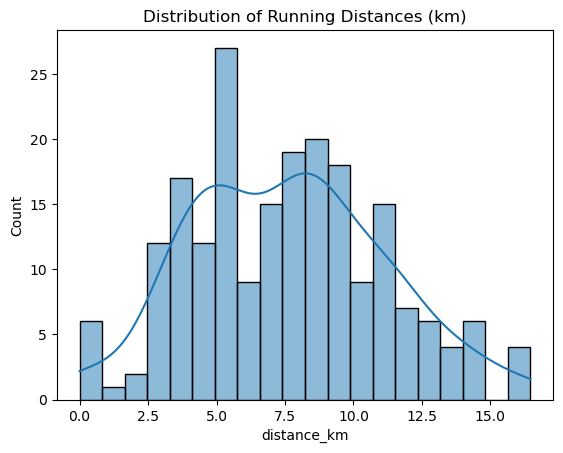

In [4]:
sns.histplot(df['distance_km'], bins=20, kde=True)
plt.title("Distribution of Running Distances (km)")
plt.show()

In [5]:
features = [
    "distance_km",
    "avg_hr",
    "avg_cadence",
    "elevation_per_km",
    "weekly_km",
    "rolling_pace",
    "hr_percent_max",
    "effort_pace"
]
corr = df[features + ["total_time_min"]].corr()
print(corr["total_time_min"].sort_values(ascending=False))

total_time_min      1.000000
distance_km         0.774569
weekly_km           0.248474
effort_pace         0.168172
rolling_pace        0.001134
avg_cadence        -0.073001
hr_percent_max     -0.076397
avg_hr             -0.124286
elevation_per_km   -0.176625
Name: total_time_min, dtype: float64


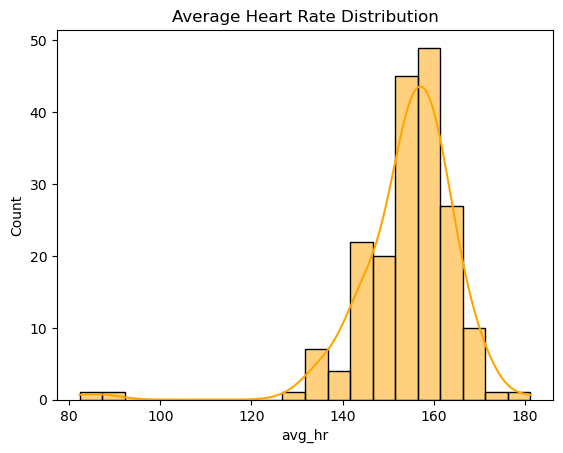

In [6]:
sns.histplot(df['avg_hr'], bins=20, kde=True, color='orange')
plt.title("Average Heart Rate Distribution")
plt.show()

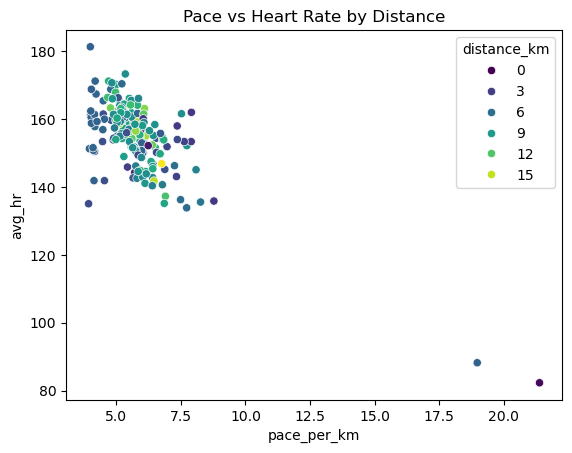

In [7]:
sns.scatterplot(x='pace_per_km', y='avg_hr', data=df, hue='distance_km', palette='viridis')
plt.title("Pace vs Heart Rate by Distance")
plt.show()


## Model Prediction

In [ ]:
output = train_model()

results = output["results"]
y_val = output["y_val"]
best_model = output["best_model"]
models = output["models"]

In [26]:
best_results = output["results"][output["results"]["Model"] == best_model]
print(best_results)

               Model      RMSE        R2
0  Linear Regression  3.876957  0.963109


In [ ]:
y_val = output["y_val"].reset_index(drop=True)
X_val = output["X_val"]

preds = best_model.predict(X_val)

df_best = pd.DataFrame({
    "Actual": y_val,
    "Predicted": preds,
    "Residual": y_val-preds
})

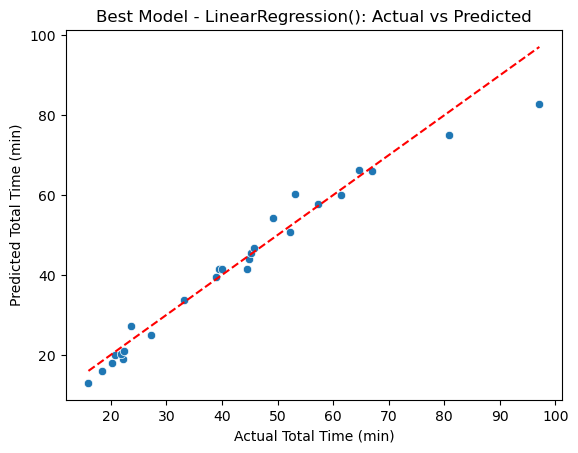

In [35]:
sns.scatterplot(x="Actual", y="Predicted", data=df_best)
sns.lineplot(x=[y_val.min(), y_val.max()],
             y=[y_val.min(), y_val.max()],
             color='red', linestyle='--')
plt.xlabel("Actual Total Time (min)")
plt.ylabel("Predicted Total Time (min)")
plt.title(f"Best Model - {best_model}: Actual vs Predicted")
plt.show()

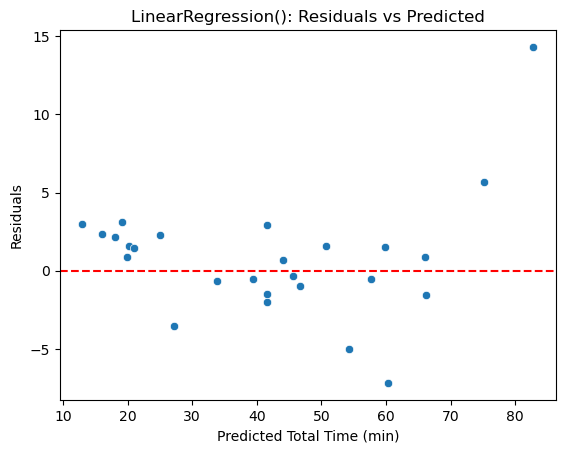

In [39]:
sns.scatterplot(x="Predicted", y="Residual", data=df_best)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Total Time (min)")
plt.ylabel("Residuals")
plt.title(f"{best_model}: Residuals vs Predicted")
plt.show()

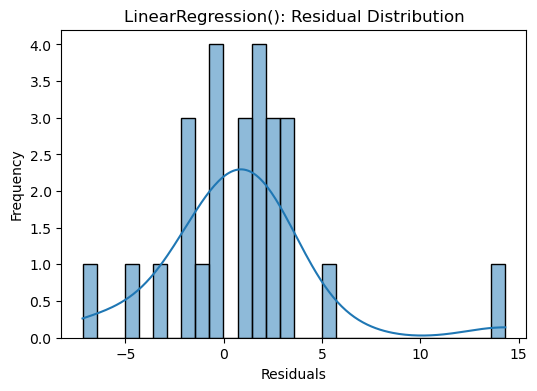

In [41]:
plt.figure(figsize=(6,4))
sns.histplot(df_best["Residual"], bins=30, kde=True)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title(f"{best_model}: Residual Distribution")
plt.show()

In [42]:
print(results)

               Model       RMSE        R2
0  Linear Regression   3.876957  0.963109
1              Ridge   5.286053  0.931419
3  Gradient Boosting  13.796359  0.532834
2      Random Forest  14.263690  0.500649
